<a href="https://colab.research.google.com/github/mike-0321/breast-cancer-that-detection-by-ai/blob/main/integrated_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1: Mount Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


## Cell 2: Install Dependencies


In [ ]:
!pip install -q monai scikit-learn pydicom opencv-python-headless



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 101.0 MB/s eta 0:00:00


## Cell 3: Import Libraries


In [ ]:
import os
import glob
import shutil
import cv2
import numpy as np
import pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from PIL import Image
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score
)
from monai.transforms import (
    Compose, EnsureType,
    RandFlip, RandRotate90, RandZoom,
    RandGaussianNoise, RandAdjustContrast
)
from monai.networks.nets import DenseNet121
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')



<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Using device: cuda


## Cell 4: Path Configuration


In [ ]:
base_dir        = '/content/drive/MyDrive/breast cancer'
train_dir       = os.path.join(base_dir, 'train')
valid_dir       = os.path.join(base_dir, 'valid')
test_dir        = os.path.join(base_dir, 'test')

processed_dir   = os.path.join(base_dir, 'processed')
processed_train = os.path.join(processed_dir, 'train')
processed_valid = os.path.join(processed_dir, 'valid')
processed_test  = os.path.join(processed_dir, 'test')

model_path = '/content/drive/MyDrive/best_densenet121_cbam.pth'
IMG_SIZE   = 224  # Increased from 96 to 224



## Cell 5: Image Loading Functions


In [ ]:
def load_dicom_image(file_path):
    """Load and normalize a DICOM image."""
    try:
        dicom = pydicom.dcmread(file_path)
        image = dicom.pixel_array
        if dicom.PhotometricInterpretation == "MONOCHROME1":
            image = np.max(image) - image
        image = image.astype(np.float32)
        image = (image - image.min()) / (image.max() - image.min() + 1e-8)
        return image
    except Exception as e:
        print(f"Error loading DICOM {file_path}: {e}")
        return None


def load_regular_image(file_path):
    """Load a regular image (PNG/JPG) as grayscale and normalize to [0, 1]."""
    try:
        img = Image.open(file_path).convert('L')
        image = np.array(img, dtype=np.float32)
        image = (image - image.min()) / (image.max() - image.min() + 1e-8)
        return image
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None


def load_image(file_path):
    """Auto-select loader based on file extension."""
    if file_path.lower().endswith('.dcm'):
        return load_dicom_image(file_path)
    else:
        return load_regular_image(file_path)




## Cell 6: White Background Detection Functions


In [ ]:
def analyze_image(image_array):
    """
    Compute brightness statistics for a grayscale image.
    Input: numpy array (H, W), range [0, 1]
    Returns: dict with mean, std, white_ratio, bright_ratio
    """
    return {
        'mean':         image_array.mean(),
        'std':          image_array.std(),
        'white_ratio':  (image_array > 0.95).sum() / image_array.size,
        'bright_ratio': (image_array > 0.8).sum()  / image_array.size,
    }


def is_white_background(stats,
                        white_ratio_thresh=0.3,
                        bright_ratio_thresh=0.5,
                        mean_thresh=0.7):
    """
    Determine whether an image has a white background.
    Triggers if ANY of the following conditions is met:
      1. White pixel ratio (>0.95) exceeds 30%
      2. Bright pixel ratio (>0.8) exceeds 50%
      3. Mean brightness > 0.7 AND std < 0.2
    """
    if stats['white_ratio'] > white_ratio_thresh:
        return True
    if stats['bright_ratio'] > bright_ratio_thresh:
        return True
    if stats['mean'] > mean_thresh and stats['std'] < 0.2:
        return True
    return False




## Cell 7: Step 1 — Scan Dataset and Detect White-Background Images


In [ ]:
splits  = ['train', 'valid', 'test']
classes = ['0', '1']

all_scan_results = []
white_bg_files   = []
normal_files     = []

print("=" * 70)
print("Step 1: Scanning dataset for white-background images...")
print("=" * 70)

for split in splits:
    for cls in classes:
        dir_path = os.path.join(base_dir, split, cls)
        files = glob.glob(os.path.join(dir_path, '*'))
        white_count = 0

        for f in tqdm(files, desc=f"{split}/class_{cls}"):
            image = load_image(f)
            if image is None:
                continue
            stats = analyze_image(image)
            stats['path']     = f
            stats['split']    = split
            stats['class']    = cls
            stats['is_white'] = is_white_background(stats)
            all_scan_results.append(stats)

            if stats['is_white']:
                white_bg_files.append(stats)
                white_count += 1
            else:
                normal_files.append(stats)

        print(f"  {split}/class_{cls}: total {len(files)}, "
              f"white-bg {white_count} ({white_count/max(len(files),1)*100:.1f}%)")

print(f"\nScan complete:")
print(f"  Total images : {len(all_scan_results)}")
print(f"  White-bg     : {len(white_bg_files)} ({len(white_bg_files)/max(len(all_scan_results),1)*100:.1f}%)")
print(f"  Normal       : {len(normal_files)} ({len(normal_files)/max(len(all_scan_results),1)*100:.1f}%)")

# Per-split / per-class summary
print(f"\n{'Dataset/Class':<25} {'Total':<10} {'White-BG':<10} {'Ratio':<10}")
print("-" * 55)
summary = defaultdict(lambda: {'total': 0, 'white': 0})
for s in all_scan_results:
    key = f"{s['split']}/class_{s['class']}"
    summary[key]['total'] += 1
    if s['is_white']:
        summary[key]['white'] += 1
for key in sorted(summary.keys()):
    v = summary[key]
    pct = v['white'] / v['total'] * 100 if v['total'] > 0 else 0
    print(f"{key:<25} {v['total']:<10} {v['white']:<10} {pct:.1f}%")

# Save white-bg file list
white_list_path = os.path.join(base_dir, 'white_bg_files.txt')
with open(white_list_path, 'w') as f:
    for s in white_bg_files:
        f.write(f"{s['path']}\tmean={s['mean']:.4f}\twhite_ratio={s['white_ratio']:.4f}\n")
print(f"\nWhite-bg file list saved to: {white_list_path}")




Step 1: Scanning dataset for white-background images...


train/class_0: 100%|██████████| 1569/1569 [00:53<00:00, 29.57it/s] 


  train/class_0: total 1569, white-bg 266 (17.0%)


train/class_1: 100%|██████████| 803/803 [00:16<00:00, 48.77it/s] 


  train/class_1: total 803, white-bg 100 (12.5%)


...

  valid/class_1: total 227, white-bg 38 (16.7%)


test/class_0: 100%|██████████| 208/208 [00:03<00:00, 53.06it/s] 


  test/class_0: total 208, white-bg 38 (18.3%)


test/class_1: 100%|██████████| 128/128 [00:02<00:00, 45.75it/s]

  test/class_1: total 128, white-bg 23 (18.0%)

Scan complete:
  Total images : 3383
  White-bg     : 550 (16.3%)
  Normal       : 2833 (83.7%)

Dataset/Class             Total      White-BG   Ratio     
-------------------------------------------------------
test/class_0              208        38         18.3%
test/class_1              128        23         18.0%
train/class_0             1569       266        17.0%
train/class_1             803        100        12.5%
valid/class_0             448        85         19.0%
valid/class_1             227        38         16.7%

White-bg file list saved to: /content/drive/MyDrive/breast cancer/white_bg_files.txt


## Cell 8: Visualize White-BG Detection Results


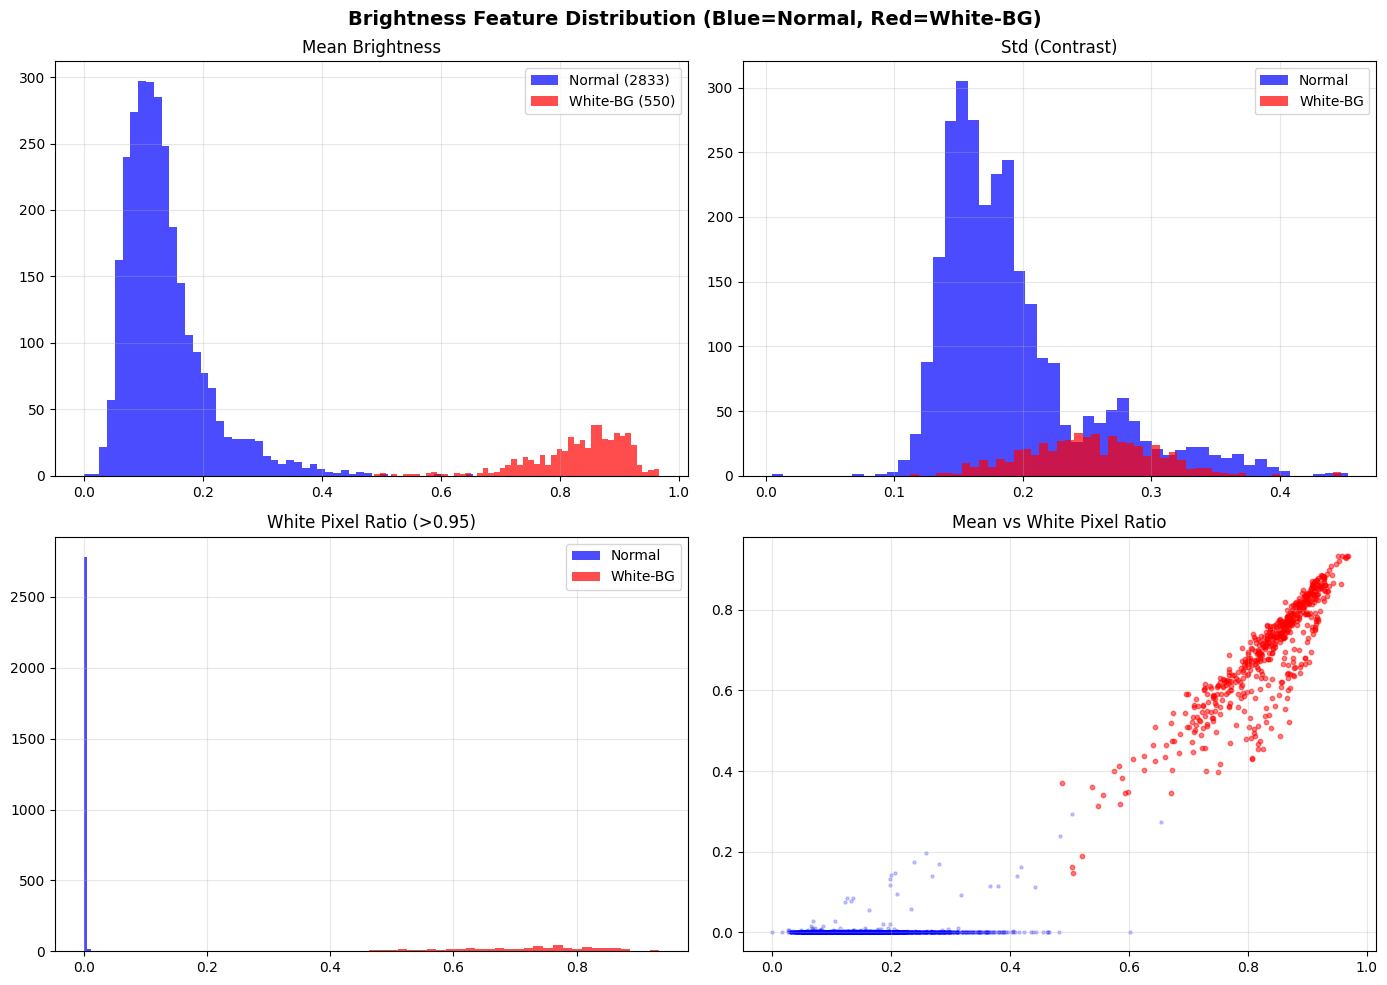

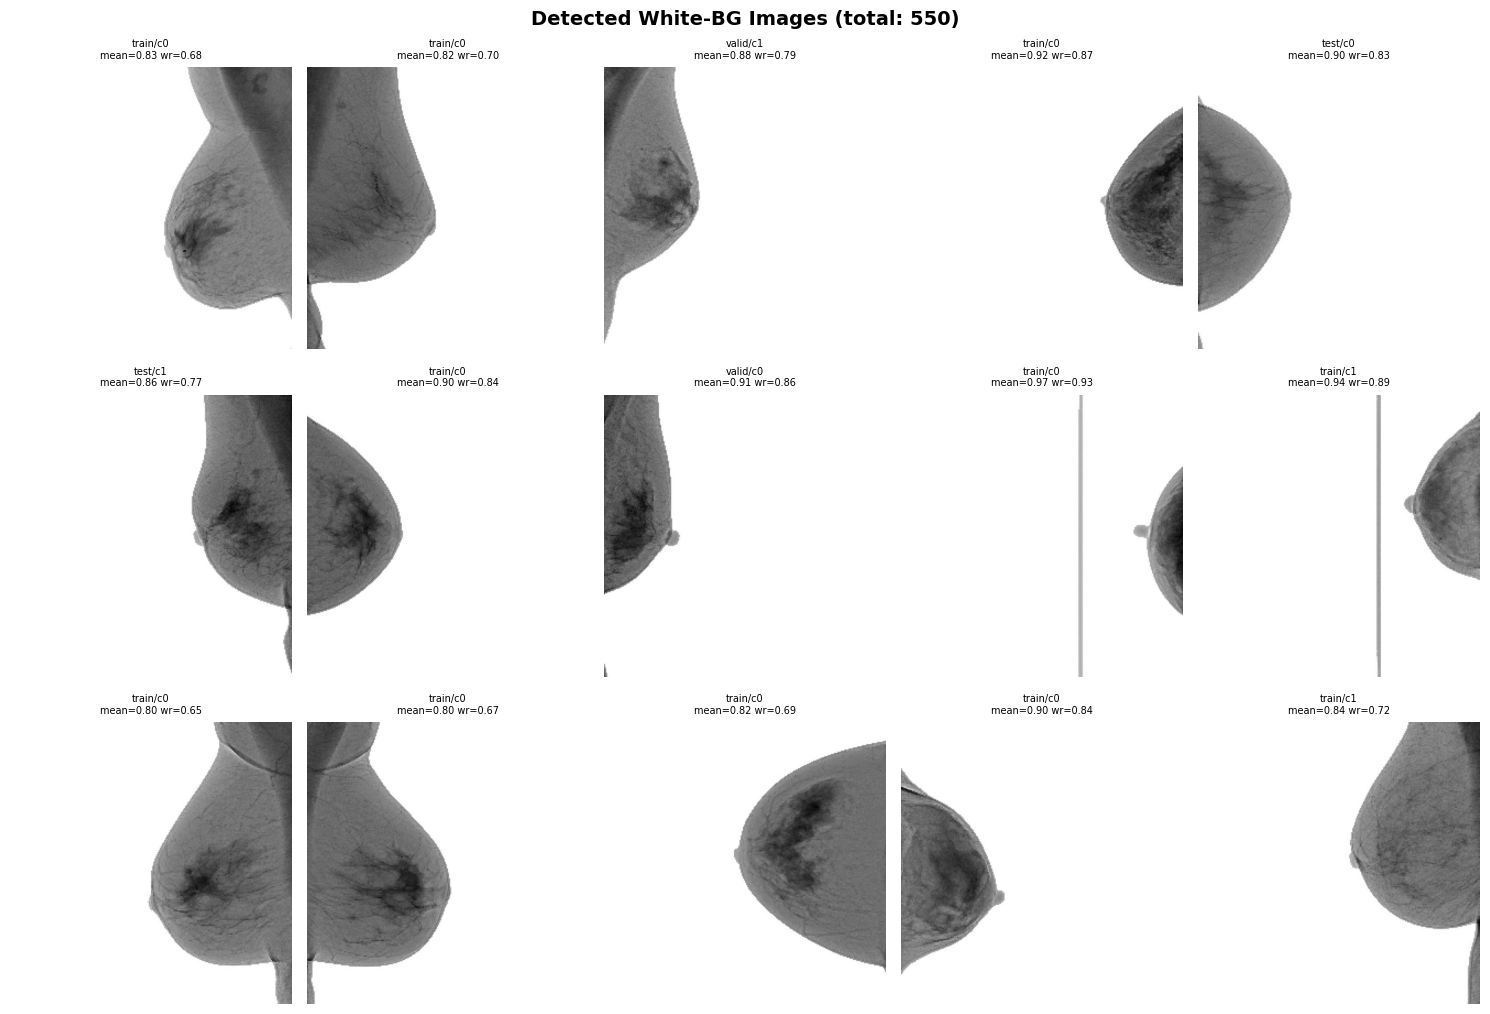

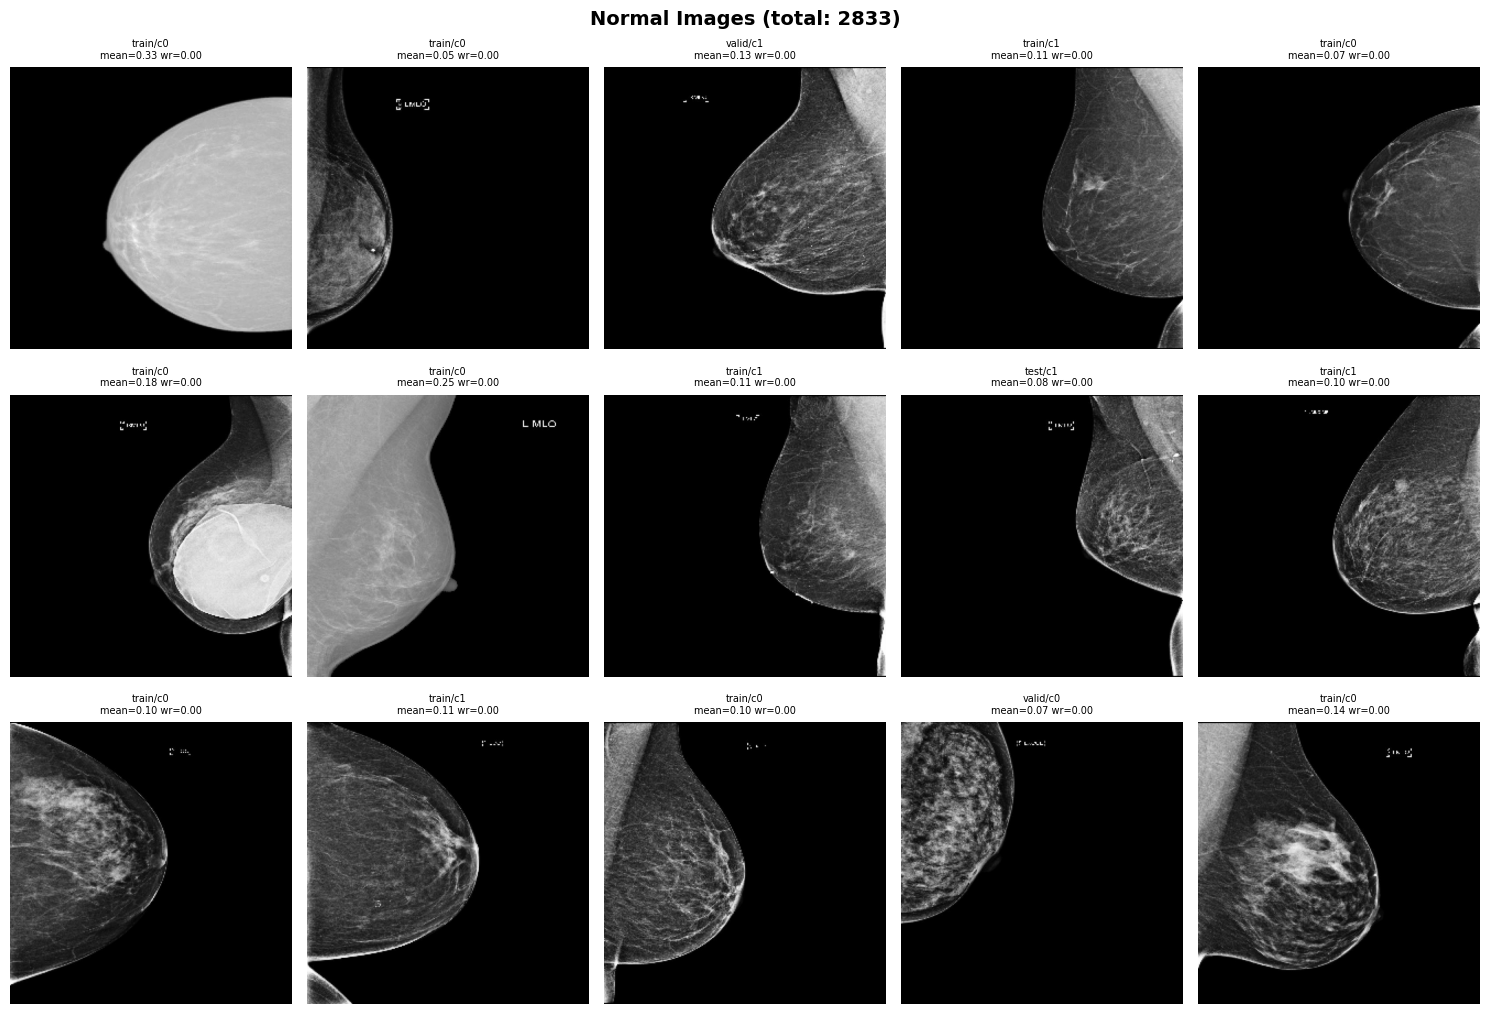

In [ ]:
# --- Distribution plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Brightness Feature Distribution (Blue=Normal, Red=White-BG)',
             fontsize=14, fontweight='bold')

normal_means = [s['mean'] for s in normal_files]
white_means  = [s['mean'] for s in white_bg_files]
axes[0, 0].hist(normal_means, bins=50, alpha=0.7, color='blue', label=f'Normal ({len(normal_files)})')
if white_means:
    axes[0, 0].hist(white_means, bins=50, alpha=0.7, color='red', label=f'White-BG ({len(white_bg_files)})')
axes[0, 0].set_title('Mean Brightness'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

normal_stds = [s['std'] for s in normal_files]
white_stds  = [s['std'] for s in white_bg_files]
axes[0, 1].hist(normal_stds, bins=50, alpha=0.7, color='blue', label='Normal')
if white_stds:
    axes[0, 1].hist(white_stds, bins=50, alpha=0.7, color='red', label='White-BG')
axes[0, 1].set_title('Std (Contrast)'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

normal_wr = [s['white_ratio'] for s in normal_files]
white_wr  = [s['white_ratio'] for s in white_bg_files]
axes[1, 0].hist(normal_wr, bins=50, alpha=0.7, color='blue', label='Normal')
if white_wr:
    axes[1, 0].hist(white_wr, bins=50, alpha=0.7, color='red', label='White-BG')
axes[1, 0].set_title('White Pixel Ratio (>0.95)'); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

for s in normal_files:
    axes[1, 1].scatter(s['mean'], s['white_ratio'], c='blue', alpha=0.2, s=5)
for s in white_bg_files:
    axes[1, 1].scatter(s['mean'], s['white_ratio'], c='red', alpha=0.5, s=10)
axes[1, 1].set_title('Mean vs White Pixel Ratio'); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'white_bg_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Show sample images ---
def show_sample_images(file_list, title, n_cols=5, n_rows=3):
    """Display a grid of sample images from a list of stats dicts."""
    n_show = min(len(file_list), n_cols * n_rows)
    if n_show == 0:
        print(f"No images found for: {title}")
        return
    indices = np.random.choice(len(file_list), n_show, replace=False)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3.5 * n_rows))
    fig.suptitle(f'{title} (total: {len(file_list)})', fontsize=14, fontweight='bold')
    for i in range(n_rows * n_cols):
        ax = axes[i // n_cols, i % n_cols] if n_rows > 1 else axes[i % n_cols]
        if i < n_show:
            s = file_list[indices[i]]
            try:
                img = Image.open(s['path']).convert('L')
                ax.imshow(np.array(img), cmap='gray')
                ax.set_title(f"{s['split']}/c{s['class']}\nmean={s['mean']:.2f} wr={s['white_ratio']:.2f}", fontsize=7)
            except:
                ax.set_title("Load failed", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(white_bg_files, "Detected White-BG Images")
show_sample_images(normal_files,   "Normal Images")




## Cell 9: Breast Region Cropping Functions


In [ ]:
def create_breast_mask(image):
    """Return indices of all non-zero pixels."""
    nonzero_indices = np.argwhere(image != 0)
    if nonzero_indices.size == 0:
        return np.array([[]], dtype=image.dtype)
    return nonzero_indices


def crop_breast_region(image, crop_x=None, crop_y=None):
    """Crop image to the smallest bounding box containing all non-zero pixels."""
    if (crop_x is None) or (crop_y is None):
        nonzero_indices = create_breast_mask(image)
        if nonzero_indices.size == 0:
            return image
        min_row, min_col = nonzero_indices.min(axis=0)
        max_row, max_col = nonzero_indices.max(axis=0) + 1
    else:
        try:
            crop_x = min(int(float(crop_x)), image.shape[1])
            crop_y = min(int(float(crop_y)), image.shape[0])
            min_row, min_col = 0, 0
            max_row, max_col = crop_y, crop_x
        except (ValueError, TypeError):
            nonzero_indices = create_breast_mask(image)
            if nonzero_indices.size == 0:
                return image
            min_row, min_col = nonzero_indices.min(axis=0)
            max_row, max_col = nonzero_indices.max(axis=0) + 1
    return image[min_row:max_row, min_col:max_col]




## Cell 10: Step 2 — Preprocess (Skip White-BG): Load → Filter → Crop → Save


In [ ]:
white_bg_set = set(s['path'] for s in white_bg_files)
print(f"White-BG set size: {len(white_bg_set)}")


def preprocess_and_save_dataset(src_dir, dst_dir, target_size=(224, 224),
                                skip_set=None):
    """
    Batch preprocessing pipeline:
      Load → White-BG filter → Crop breast region → Resize → Expand to 3-ch → Save .npy
    """
    total_processed    = 0
    total_skipped_white = 0
    total_skipped_exist = 0
    total_failed       = 0

    if skip_set is None:
        skip_set = set()

    for class_name in ['0', '1']:
        src_class_dir = os.path.join(src_dir, class_name)
        dst_class_dir = os.path.join(dst_dir, class_name)
        os.makedirs(dst_class_dir, exist_ok=True)

        files = glob.glob(os.path.join(src_class_dir, '*'))
        split_name = os.path.basename(src_dir)
        print(f"\nProcessing {split_name}/class_{class_name}: {len(files)} files")

        for file_path in tqdm(files, desc=f"Class {class_name}"):
            filename  = os.path.splitext(os.path.basename(file_path))[0]
            save_path = os.path.join(dst_class_dir, f"{filename}.npy")

            # Skip already processed
            if os.path.exists(save_path):
                total_skipped_exist += 1
                continue

            # Skip white-background images
            if file_path in skip_set:
                total_skipped_white += 1
                continue

            # Load
            image = load_image(file_path)
            if image is None:
                total_failed += 1
                continue

            # Crop breast region
            cropped = crop_breast_region(image)
            if cropped.size == 0 or cropped.ndim != 2:
                cropped = image

            # Resize
            pil_img = Image.fromarray((cropped * 255).astype(np.uint8), mode='L')
            pil_img = pil_img.resize(target_size, Image.BILINEAR)
            resized = np.array(pil_img, dtype=np.float32) / 255.0

            # Expand to 3 channels (C, H, W)
            image_3ch = np.stack([resized, resized, resized], axis=0)

            # Save
            np.save(save_path, image_3ch)
            total_processed += 1

    print(f"\n  Processed: {total_processed}, Already exist: {total_skipped_exist}, "
          f"White-BG skipped: {total_skipped_white}, Failed: {total_failed}")


# Clear old preprocessed data (previous run had no white-bg filtering)
if os.path.exists(processed_dir):
    shutil.rmtree(processed_dir)
    print("Cleared old preprocessed data, reprocessing...\n")

print("=" * 70)
print("Step 2: Preprocessing dataset (skipping white-background images)...")
print("=" * 70)

preprocess_and_save_dataset(train_dir, processed_train,
                            target_size=(IMG_SIZE, IMG_SIZE), skip_set=white_bg_set)
preprocess_and_save_dataset(valid_dir, processed_valid,
                            target_size=(IMG_SIZE, IMG_SIZE), skip_set=white_bg_set)
preprocess_and_save_dataset(test_dir, processed_test,
                            target_size=(IMG_SIZE, IMG_SIZE), skip_set=white_bg_set)




White-BG set size: 550
Cleared old preprocessed data, reprocessing...

Step 2: Preprocessing dataset (skipping white-background images)...

Processing train/class_0: 1569 files


Class 0:   0%|          | 0/1569 [00:00<?, ?it/s]/tmp/ipykernel_5209/1614069163.py:54: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray((cropped * 255).astype(np.uint8), mode='L')
Class 0: 100%|██████████| 1569/1569 [00:47<00:00, 33.30it/s]



Processing train/class_1: 803 files


Class 1: 100%|██████████| 803/803 [00:24<00:00, 33.01it/s]



  Processed: 2006, Already exist: 0, White-BG skipped: 366, Failed: 0

Processing valid/class_0: 448 files


...


  Processed: 552, Already exist: 0, White-BG skipped: 123, Failed: 0

Processing test/class_0: 208 files


Class 0: 100%|██████████| 208/208 [00:06<00:00, 33.58it/s]



Processing test/class_1: 128 files


Class 1: 100%|██████████| 128/128 [00:03<00:00, 37.20it/s]


  Processed: 275, Already exist: 0, White-BG skipped: 61, Failed: 0


## Cell 11: Visualize Preprocessing Comparison (Optional)


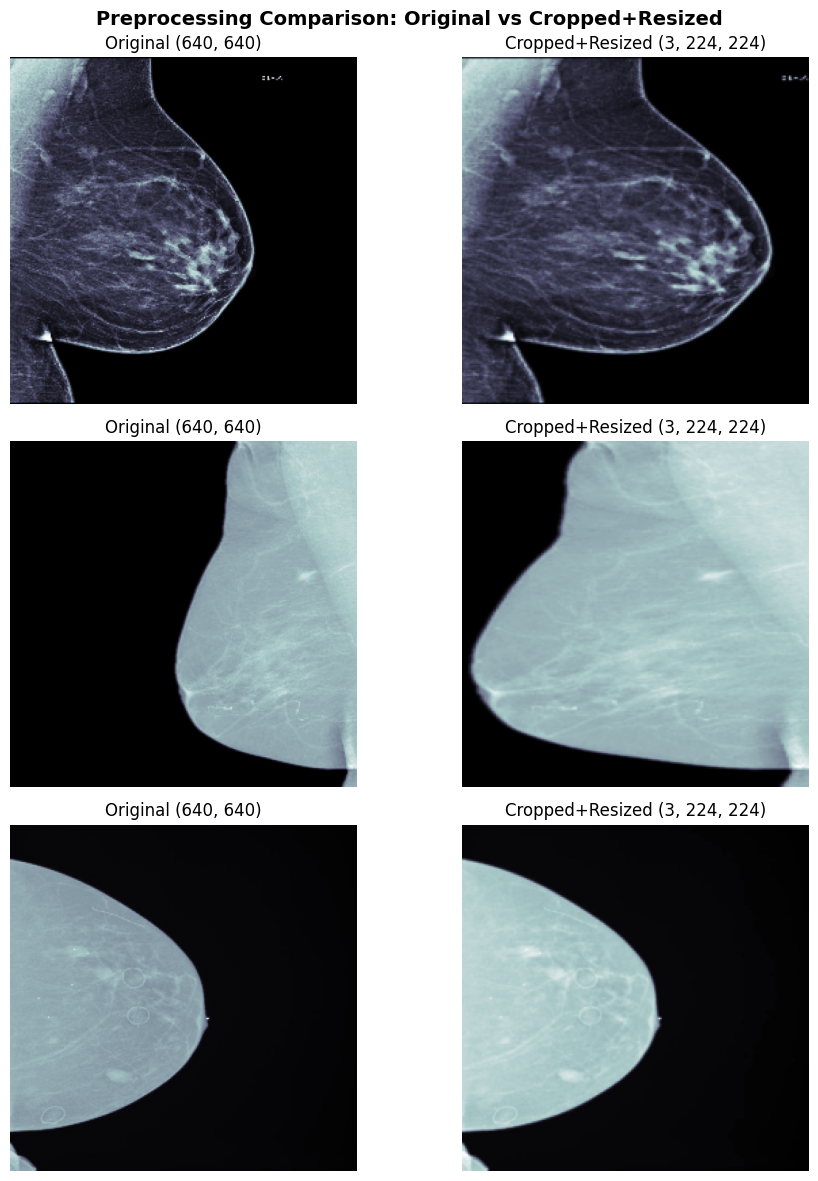

In [ ]:
def visualize_preprocessing(src_dir, dst_dir, class_name='1', n_samples=3):
    """Show side-by-side comparison of original vs preprocessed images."""
    src_files = glob.glob(os.path.join(src_dir, class_name, '*'))
    valid_pairs = []
    for src_path in src_files:
        filename = os.path.splitext(os.path.basename(src_path))[0]
        npy_path = os.path.join(dst_dir, class_name, f"{filename}.npy")
        if os.path.exists(npy_path):
            valid_pairs.append((src_path, npy_path))
        if len(valid_pairs) >= n_samples:
            break

    if not valid_pairs:
        print("No paired images found for comparison")
        return

    fig, axes = plt.subplots(len(valid_pairs), 2, figsize=(10, 4 * len(valid_pairs)))
    if len(valid_pairs) == 1:
        axes = axes.reshape(1, -1)
    fig.suptitle('Preprocessing Comparison: Original vs Cropped+Resized',
                 fontsize=14, fontweight='bold')

    for i, (src_path, npy_path) in enumerate(valid_pairs):
        original = load_image(src_path)
        if original is not None:
            axes[i, 0].imshow(original, cmap='bone')
            axes[i, 0].set_title(f'Original {original.shape}')
            axes[i, 0].axis('off')
        processed = np.load(npy_path)
        axes[i, 1].imshow(processed[0], cmap='bone')
        axes[i, 1].set_title(f'Cropped+Resized {processed.shape}')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

visualize_preprocessing(train_dir, processed_train, class_name='1', n_samples=3)




## Cell 12: Step 3 — Build File Lists (from preprocessed directory)


In [ ]:
def build_file_list(data_dir):
    """Build file list from preprocessed .npy directory."""
    image_files, labels = [], []
    for class_name in ['0', '1']:
        class_dir = os.path.join(data_dir, class_name)
        files = glob.glob(os.path.join(class_dir, '*.npy'))
        image_files.extend(files)
        labels.extend([int(class_name)] * len(files))
    return image_files, labels

train_files, train_labels = build_file_list(processed_train)
valid_files, valid_labels = build_file_list(processed_valid)
test_files,  test_labels  = build_file_list(processed_test)

print(f'After white-BG filtering:')
print(f'  Train: {len(train_files)} | Valid: {len(valid_files)} | Test: {len(test_files)}')
print(f'  Train class 0: {train_labels.count(0)}, class 1: {train_labels.count(1)}')




After white-BG filtering:
  Train: 2006 | Valid: 552 | Test: 275
  Train class 0: 1303, class 1: 703


## Cell 13: Custom Dataset (loads preprocessed .npy files)


In [ ]:
class PreprocessedMammogramDataset(Dataset):
    """Dataset that loads preprocessed .npy files (shape: 3×H×W)."""
    def __init__(self, image_files, labels, transform=None):
        self.image_files = image_files
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = np.load(self.image_files[idx]).astype(np.float32)
        image = torch.from_numpy(image)
        label = self.labels[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label




## Cell 14: Data Augmentation + DataLoader


In [ ]:
train_transforms = Compose([
    EnsureType(),
    RandFlip(prob=0.5, spatial_axis=0),
    RandFlip(prob=0.5, spatial_axis=1),
    RandRotate90(prob=0.5),
    RandZoom(prob=0.3, min_zoom=0.85, max_zoom=1.15),
    RandGaussianNoise(prob=0.2, mean=0.0, std=0.05),
    RandAdjustContrast(prob=0.2, gamma=(0.8, 1.2)),
])
val_transforms = Compose([EnsureType()])

BATCH_SIZE  = 16
NUM_WORKERS = 2

train_ds = PreprocessedMammogramDataset(train_files, train_labels, transform=train_transforms)
valid_ds = PreprocessedMammogramDataset(valid_files, valid_labels, transform=val_transforms)
test_ds  = PreprocessedMammogramDataset(test_files,  test_labels,  transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train batches: {len(train_loader)} | Valid batches: {len(valid_loader)}')
sample_img, sample_label = train_ds[0]
print(f'Sample shape: {sample_img.shape}, label: {sample_label}')




Train batches: 126 | Valid batches: 35
Sample shape: torch.Size([3, 224, 224]), label: 0


## Cell 15: CBAM Module


In [ ]:
class ChannelAttention(nn.Module):
    """Channel Attention: learns per-channel importance weights."""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(in_channels // reduction, 8)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, mid, bias=False),
            nn.ReLU(inplace=False),
            nn.Linear(mid, in_channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        avg = self.fc(self.avg_pool(x).view(b, c))
        mx  = self.fc(self.max_pool(x).view(b, c))
        return x * self.sigmoid(avg + mx).view(b, c, 1, 1)


class SpatialAttention(nn.Module):
    """Spatial Attention: learns per-location importance weights."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    """CBAM: Convolutional Block Attention Module (Channel → Spatial)."""
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attn = ChannelAttention(in_channels, reduction)
        self.spatial_attn = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.spatial_attn(self.channel_attn(x))




## Cell 16: Model Definition (DenseNet121 + CBAM)


In [ ]:
class DenseNetWithCBAM(nn.Module):
    """DenseNet121 backbone + CBAM attention + classification head."""
    def __init__(self, num_classes=2, dropout_rate=0.4):
        super().__init__()
        backbone = DenseNet121(spatial_dims=2, in_channels=3, out_channels=1024)
        self.features = backbone.features
        self.cbam = CBAM(in_channels=1024, reduction=16, kernel_size=7)
        self.classifier = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=False),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.cbam(self.features(x)))

model = DenseNetWithCBAM(num_classes=2, dropout_rate=0.4).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")




Total parameters: 7,347,940


## Cell 17: Training Configuration


In [ ]:
MAX_EPOCHS   = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 10

n0 = train_labels.count(0)
n1 = train_labels.count(1)
w0 = (n0 + n1) / (2 * n0)
w1 = (n0 + n1) / (2 * n1)
class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)
print(f'Class weights -> 0: {w0:.4f}, 1: {w1:.4f}')

loss_fn   = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-6)




Class weights -> 0: 0.7698, 1: 1.4267


## Cell 18: Training Loop


In [ ]:
train_losses, val_accs, val_losses, lr_history = [], [], [], []
best_val_acc   = 0.0
patience_count = 0

for epoch in range(MAX_EPOCHS):
    # --- Train ---
    model.train()
    epoch_loss, steps = 0.0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{MAX_EPOCHS}]")
    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(imgs), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        steps += 1
        loop.set_postfix(avg_loss=epoch_loss / steps)

    avg_train_loss = epoch_loss / steps
    train_losses.append(avg_train_loss)
    lr_history.append(optimizer.param_groups[0]['lr'])
    scheduler.step()

    # --- Validate ---
    model.eval()
    correct, total_val, val_loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for imgs, labels in valid_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            val_loss_sum += loss_fn(outputs, labels).item()
            correct   += (torch.argmax(outputs, 1) == labels).sum().item()
            total_val += len(labels)

    val_acc      = correct / total_val
    avg_val_loss = val_loss_sum / len(valid_loader)
    val_accs.append(val_acc)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1:02d}/{MAX_EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | LR: {lr_history[-1]:.2e}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_path)
        print(f"  Best model saved (Val Acc: {best_val_acc:.4f})")
        patience_count = 0
    else:
        patience_count += 1

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")




Epoch [1/30]: 100%|██████████| 126/126 [00:46<00:00,  2.72it/s, avg_loss=0.682]


Epoch [01/30] Train Loss: 0.6820 | Val Loss: 0.6537 | Val Acc: 0.6123 | LR: 1.00e-04
  Best model saved (Val Acc: 0.6123)


Epoch [2/30]: 100%|██████████| 126/126 [00:42<00:00,  2.99it/s, avg_loss=0.674]


Epoch [02/30] Train Loss: 0.6738 | Val Loss: 0.6651 | Val Acc: 0.5670 | LR: 9.97e-05


Epoch [3/30]: 100%|██████████| 126/126 [00:42<00:00,  2.96it/s, avg_loss=0.677]


...

Epoch [09/30] Train Loss: 0.6652 | Val Loss: 0.6859 | Val Acc: 0.5489 | LR: 8.36e-05


Epoch [10/30]: 100%|██████████| 126/126 [00:38<00:00,  3.25it/s, avg_loss=0.669]


Epoch [10/30] Train Loss: 0.6685 | Val Loss: 0.7106 | Val Acc: 0.5435 | LR: 7.96e-05


Epoch [11/30]: 100%|██████████| 126/126 [00:38<00:00,  3.30it/s, avg_loss=0.666]


Epoch [11/30] Train Loss: 0.6659 | Val Loss: 0.6615 | Val Acc: 0.5960 | LR: 7.52e-05

Early stopping at epoch 11

Best Validation Accuracy: 0.6123


## Cell 19: Training Curves


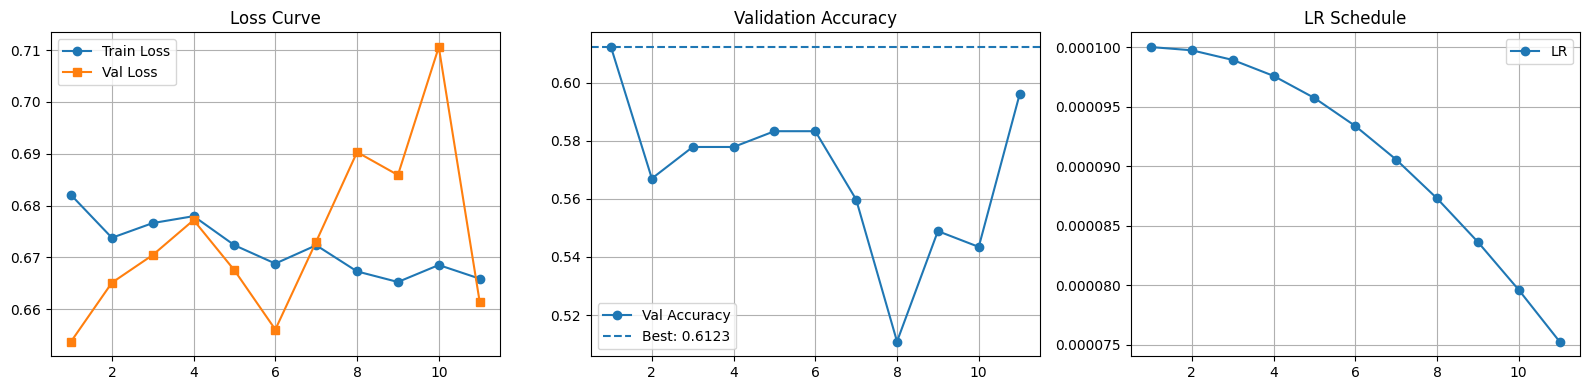

In [ ]:
epochs_ran = len(train_losses)
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(x, train_losses, marker='o', label='Train Loss')
axes[0].plot(x, val_losses,   marker='s', label='Val Loss')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(x, val_accs, marker='o', label='Val Accuracy')
axes[1].axhline(y=best_val_acc, linestyle='--', label=f'Best: {best_val_acc:.4f}')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(True)
axes[2].plot(x, lr_history, marker='o', label='LR')
axes[2].set_title('LR Schedule'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'training_curve_cbam.png'), dpi=150)
plt.show()




## Cell 20: Evaluate on Validation Set


In [ ]:
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

all_preds, all_labels_eval, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in valid_loader:
        outputs = model(imgs.to(device))
        all_probs.extend(F.softmax(outputs, 1)[:, 1].cpu().numpy())
        all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
        all_labels_eval.extend(labels.numpy())

all_preds       = np.array(all_preds)
all_labels_eval = np.array(all_labels_eval)
all_probs       = np.array(all_probs)




## Cell 21: Confusion Matrix + Classification Report


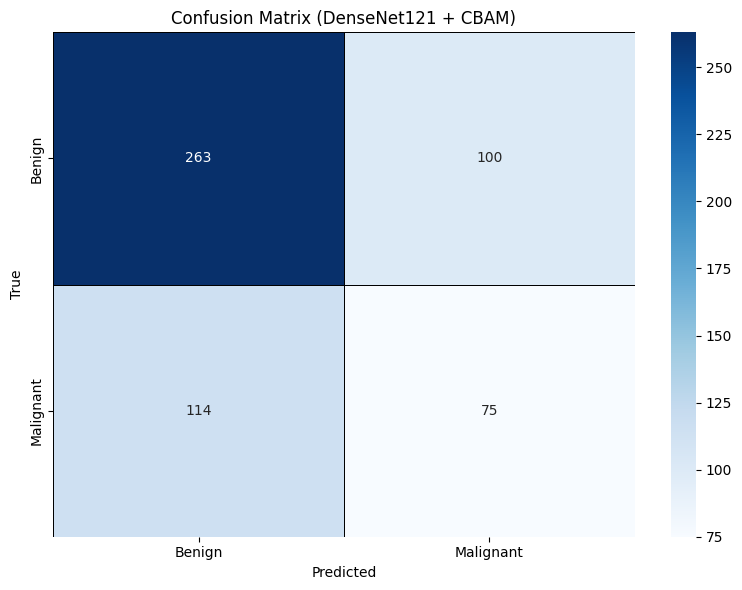


===== Classification Metrics =====
Accuracy : 0.6123
Precision: 0.4286
Recall   : 0.3968
F1-score : 0.4121
AUC      : 0.6000

===== Classification Report =====
              precision    recall  f1-score   support

      Benign     0.6976    0.7245    0.7108       363
   Malignant     0.4286    0.3968    0.4121       189

    accuracy                         0.6123       552
   macro avg     0.5631    0.5607    0.5614       552
weighted avg     0.6055    0.6123    0.6085       552



In [ ]:
CLASS_NAMES = ['Benign', 'Malignant']
cm = confusion_matrix(all_labels_eval, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='black')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix (DenseNet121 + CBAM)')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'confusion_matrix_cbam.png'), dpi=150, bbox_inches='tight')
plt.show()

acc  = accuracy_score(all_labels_eval, all_preds)
prec = precision_score(all_labels_eval, all_preds, average='binary')
rec  = recall_score(all_labels_eval, all_preds, average='binary')
f1   = f1_score(all_labels_eval, all_preds, average='binary')
try:
    auc = roc_auc_score(all_labels_eval, all_probs)
except:
    auc = None

print("\n===== Classification Metrics =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
if auc is not None:
    print(f"AUC      : {auc:.4f}")
print("\n===== Classification Report =====")
print(classification_report(all_labels_eval, all_preds,
                            target_names=CLASS_NAMES, digits=4))




## Cell 22: Grad-CAM Attention Visualization Tool


In [ ]:
# Purpose: Overlay attention heatmaps onto original mammogram images to
#          verify that the CBAM attention mechanism focuses on the correct
#          lesion regions and is not being misled by background artifacts.
#
# Reference: Selvaraju et al., "Grad-CAM: Visual Explanations from Deep
#            Networks via Gradient-based Localization", ICCV 2017
# ============================================================================

class GradCAM:
    """
    Grad-CAM: Gradient-weighted Class Activation Mapping.

    Computes the gradient of the target class score w.r.t. the feature maps
    of a specified layer, then produces a heatmap indicating which spatial
    regions contributed most to the prediction.
    """

    def __init__(self, model, target_layer):
        """
        Args:
            model:        Trained model in eval mode.
            target_layer: The layer whose activations/gradients will be captured
                          (typically the CBAM output or the last conv layer).
        """
        self.model = model
        self.target_layer = target_layer
        self.gradients   = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        """Register forward/backward hooks to capture activations and gradients."""
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class=None):
        """
        Generate Grad-CAM heatmap for a single input image.

        Args:
            input_tensor: Image tensor of shape (1, C, H, W).
            target_class: Class index to visualize. If None, uses predicted class.

        Returns:
            heatmap:    Normalized heatmap as numpy array (H, W), range [0, 1].
            pred_class: Predicted class index.
            pred_prob:  Probability of the target class.
        """
        self.model.eval()
        output     = self.model(input_tensor)
        pred_probs = torch.softmax(output, dim=1)

        if target_class is None:
            target_class = output.argmax(dim=1).item()
        pred_prob = pred_probs[0, target_class].item()

        # Backward pass: compute gradient of target class score
        self.model.zero_grad()
        output[0, target_class].backward()

        # Global average pool the gradients -> per-channel weights
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)

        # Weighted combination of forward activations
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        # Normalize to [0, 1]
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        # Upsample to input resolution
        cam_resized = cv2.resize(cam, (input_tensor.shape[3], input_tensor.shape[2]))
        return cam_resized, target_class, pred_prob


def overlay_heatmap(image, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Blend a colored heatmap onto a grayscale image.

    Args:
        image:    Grayscale image (H, W) or (C, H, W), range [0, 1].
        heatmap:  Attention heatmap (H, W), range [0, 1].
        alpha:    Heatmap opacity.
        colormap: OpenCV colormap.

    Returns:
        overlaid: Blended RGB image (H, W, 3), range [0, 1].
    """
    if image.ndim == 2:
        image_3ch = np.stack([image, image, image], axis=-1)
    elif image.shape[0] == 3:
        image_3ch = np.transpose(image, (1, 2, 0))
    else:
        image_3ch = image

    heatmap_color = cv2.applyColorMap((heatmap * 255).astype(np.uint8), colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip((1 - alpha) * image_3ch + alpha * heatmap_color, 0, 1)




## Cell 23: Generate Grad-CAM Visualizations for Validation Samples


In [ ]:
# Load best model
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Target layer: CBAM output (to see what the attention module highlights)
grad_cam = GradCAM(model, target_layer=model.cbam)

# Select samples: n per class
n_samples_per_class = 5
benign_indices    = [i for i, l in enumerate(valid_ds.labels) if l == 0]
malignant_indices = [i for i, l in enumerate(valid_ds.labels) if l == 1]
np.random.seed(42)
selected_benign    = np.random.choice(benign_indices,
                                       min(n_samples_per_class, len(benign_indices)),
                                       replace=False)
selected_malignant = np.random.choice(malignant_indices,
                                       min(n_samples_per_class, len(malignant_indices)),
                                       replace=False)
selected_indices = np.concatenate([selected_benign, selected_malignant])
print(f"Selected {len(selected_benign)} benign + {len(selected_malignant)} malignant samples")

def disable_inplace_relu(module):
    for child in module.children():
        if isinstance(child, nn.ReLU):
            child.inplace = False
        else:
            disable_inplace_relu(child)

disable_inplace_relu(model)


Selected 5 benign + 5 malignant samples


## Cell 24: Display Grad-CAM Results (4-column layout per sample)


/tmp/ipykernel_5209/562020770.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


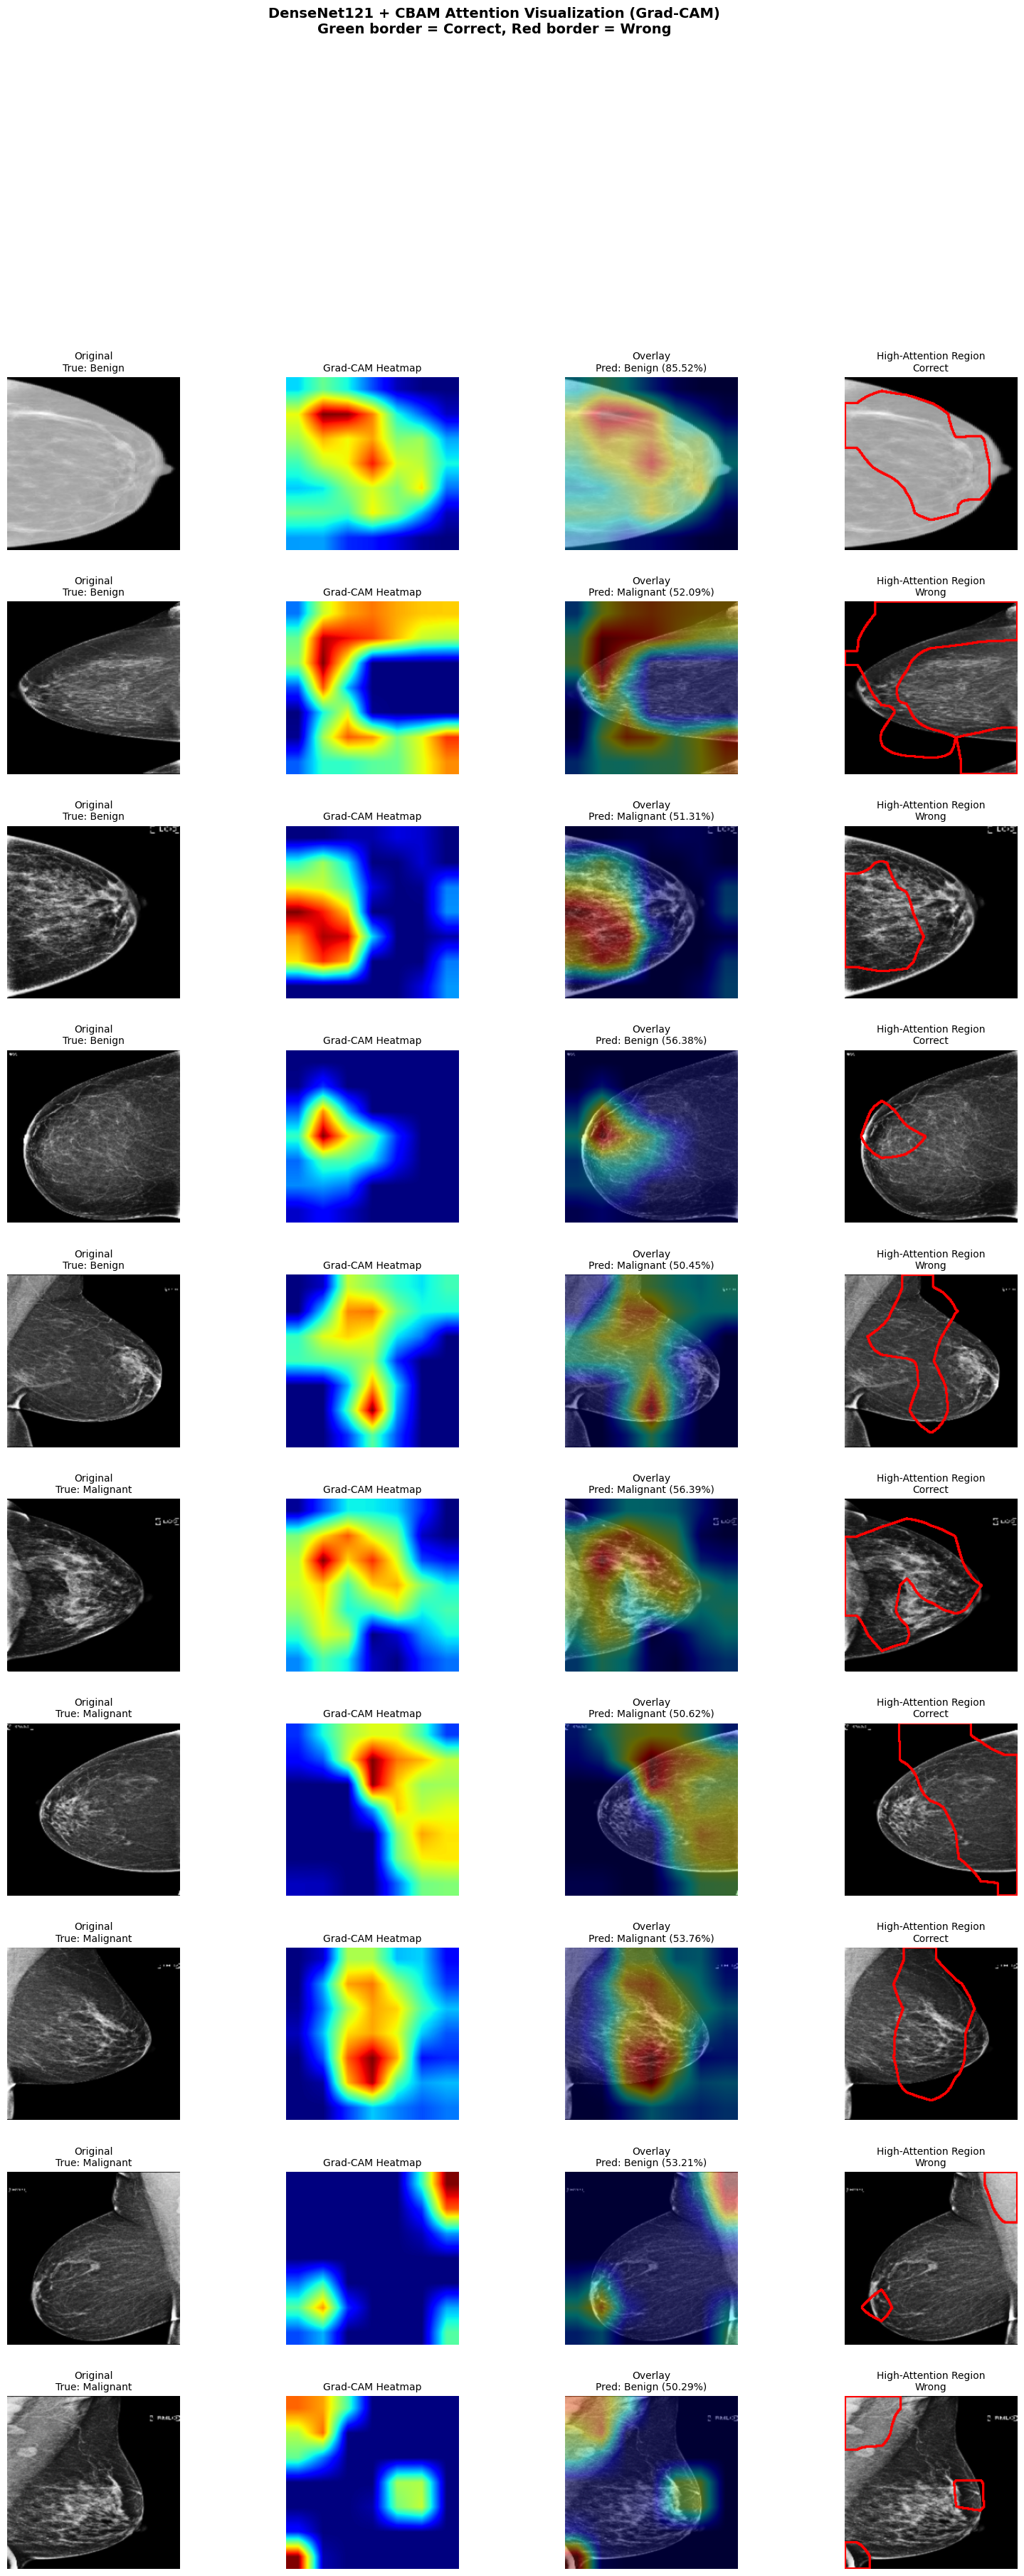

Saved to: /content/drive/MyDrive/breast cancer/gradcam_attention_visualization.png


In [ ]:
# Columns: Original | Heatmap | Overlay | High-Attention Contour
# Green border = correct prediction, Red border = wrong prediction

fig = plt.figure(figsize=(20, 4 * len(selected_indices)))
gs  = gridspec.GridSpec(len(selected_indices), 4, width_ratios=[1, 1, 1, 1],
                        wspace=0.05, hspace=0.3)

for row_idx, sample_idx in enumerate(selected_indices):
    image_tensor, true_label = valid_ds[sample_idx]
    input_tensor = image_tensor.unsqueeze(0).to(device).requires_grad_(True)

    heatmap, pred_class, pred_prob = grad_cam.generate(input_tensor)
    original_image = image_tensor[0].numpy()
    overlay = overlay_heatmap(original_image, heatmap, alpha=0.4)

    is_correct   = (pred_class == true_label)
    status       = "Correct" if is_correct else "Wrong"
    border_color = 'green' if is_correct else 'red'

    # Column 1: Original image
    ax1 = fig.add_subplot(gs[row_idx, 0])
    ax1.imshow(original_image, cmap='gray')
    ax1.set_title(f'Original\nTrue: {CLASS_NAMES[true_label]}', fontsize=10)
    ax1.axis('off')
    for spine in ax1.spines.values():
        spine.set_edgecolor(border_color); spine.set_linewidth(3); spine.set_visible(True)

    # Column 2: Heatmap
    ax2 = fig.add_subplot(gs[row_idx, 1])
    ax2.imshow(heatmap, cmap='jet', vmin=0, vmax=1)
    ax2.set_title('Grad-CAM Heatmap', fontsize=10)
    ax2.axis('off')

    # Column 3: Overlay
    ax3 = fig.add_subplot(gs[row_idx, 2])
    ax3.imshow(overlay)
    ax3.set_title(f'Overlay\nPred: {CLASS_NAMES[pred_class]} ({pred_prob:.2%})', fontsize=10)
    ax3.axis('off')
    for spine in ax3.spines.values():
        spine.set_edgecolor(border_color); spine.set_linewidth(3); spine.set_visible(True)

    # Column 4: High-attention region contours (threshold > 0.5)
    ax4 = fig.add_subplot(gs[row_idx, 3])
    high_attention = (heatmap > 0.5).astype(np.uint8) * 255
    contours, _ = cv2.findContours(high_attention, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_img = (np.stack([original_image]*3, axis=-1) * 255).astype(np.uint8)
    cv2.drawContours(contour_img, contours, -1, (255, 0, 0), 2)
    ax4.imshow(contour_img)
    ax4.set_title(f'High-Attention Region\n{status}', fontsize=10)
    ax4.axis('off')
    for spine in ax4.spines.values():
        spine.set_edgecolor(border_color); spine.set_linewidth(3); spine.set_visible(True)

plt.suptitle('DenseNet121 + CBAM Attention Visualization (Grad-CAM)\n'
             'Green border = Correct, Red border = Wrong',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'gradcam_attention_visualization.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {os.path.join(base_dir, 'gradcam_attention_visualization.png')}")




## Cell 25: Compare Backbone vs CBAM Attention



Comparison: DenseNet121 backbone output vs CBAM-enhanced attention


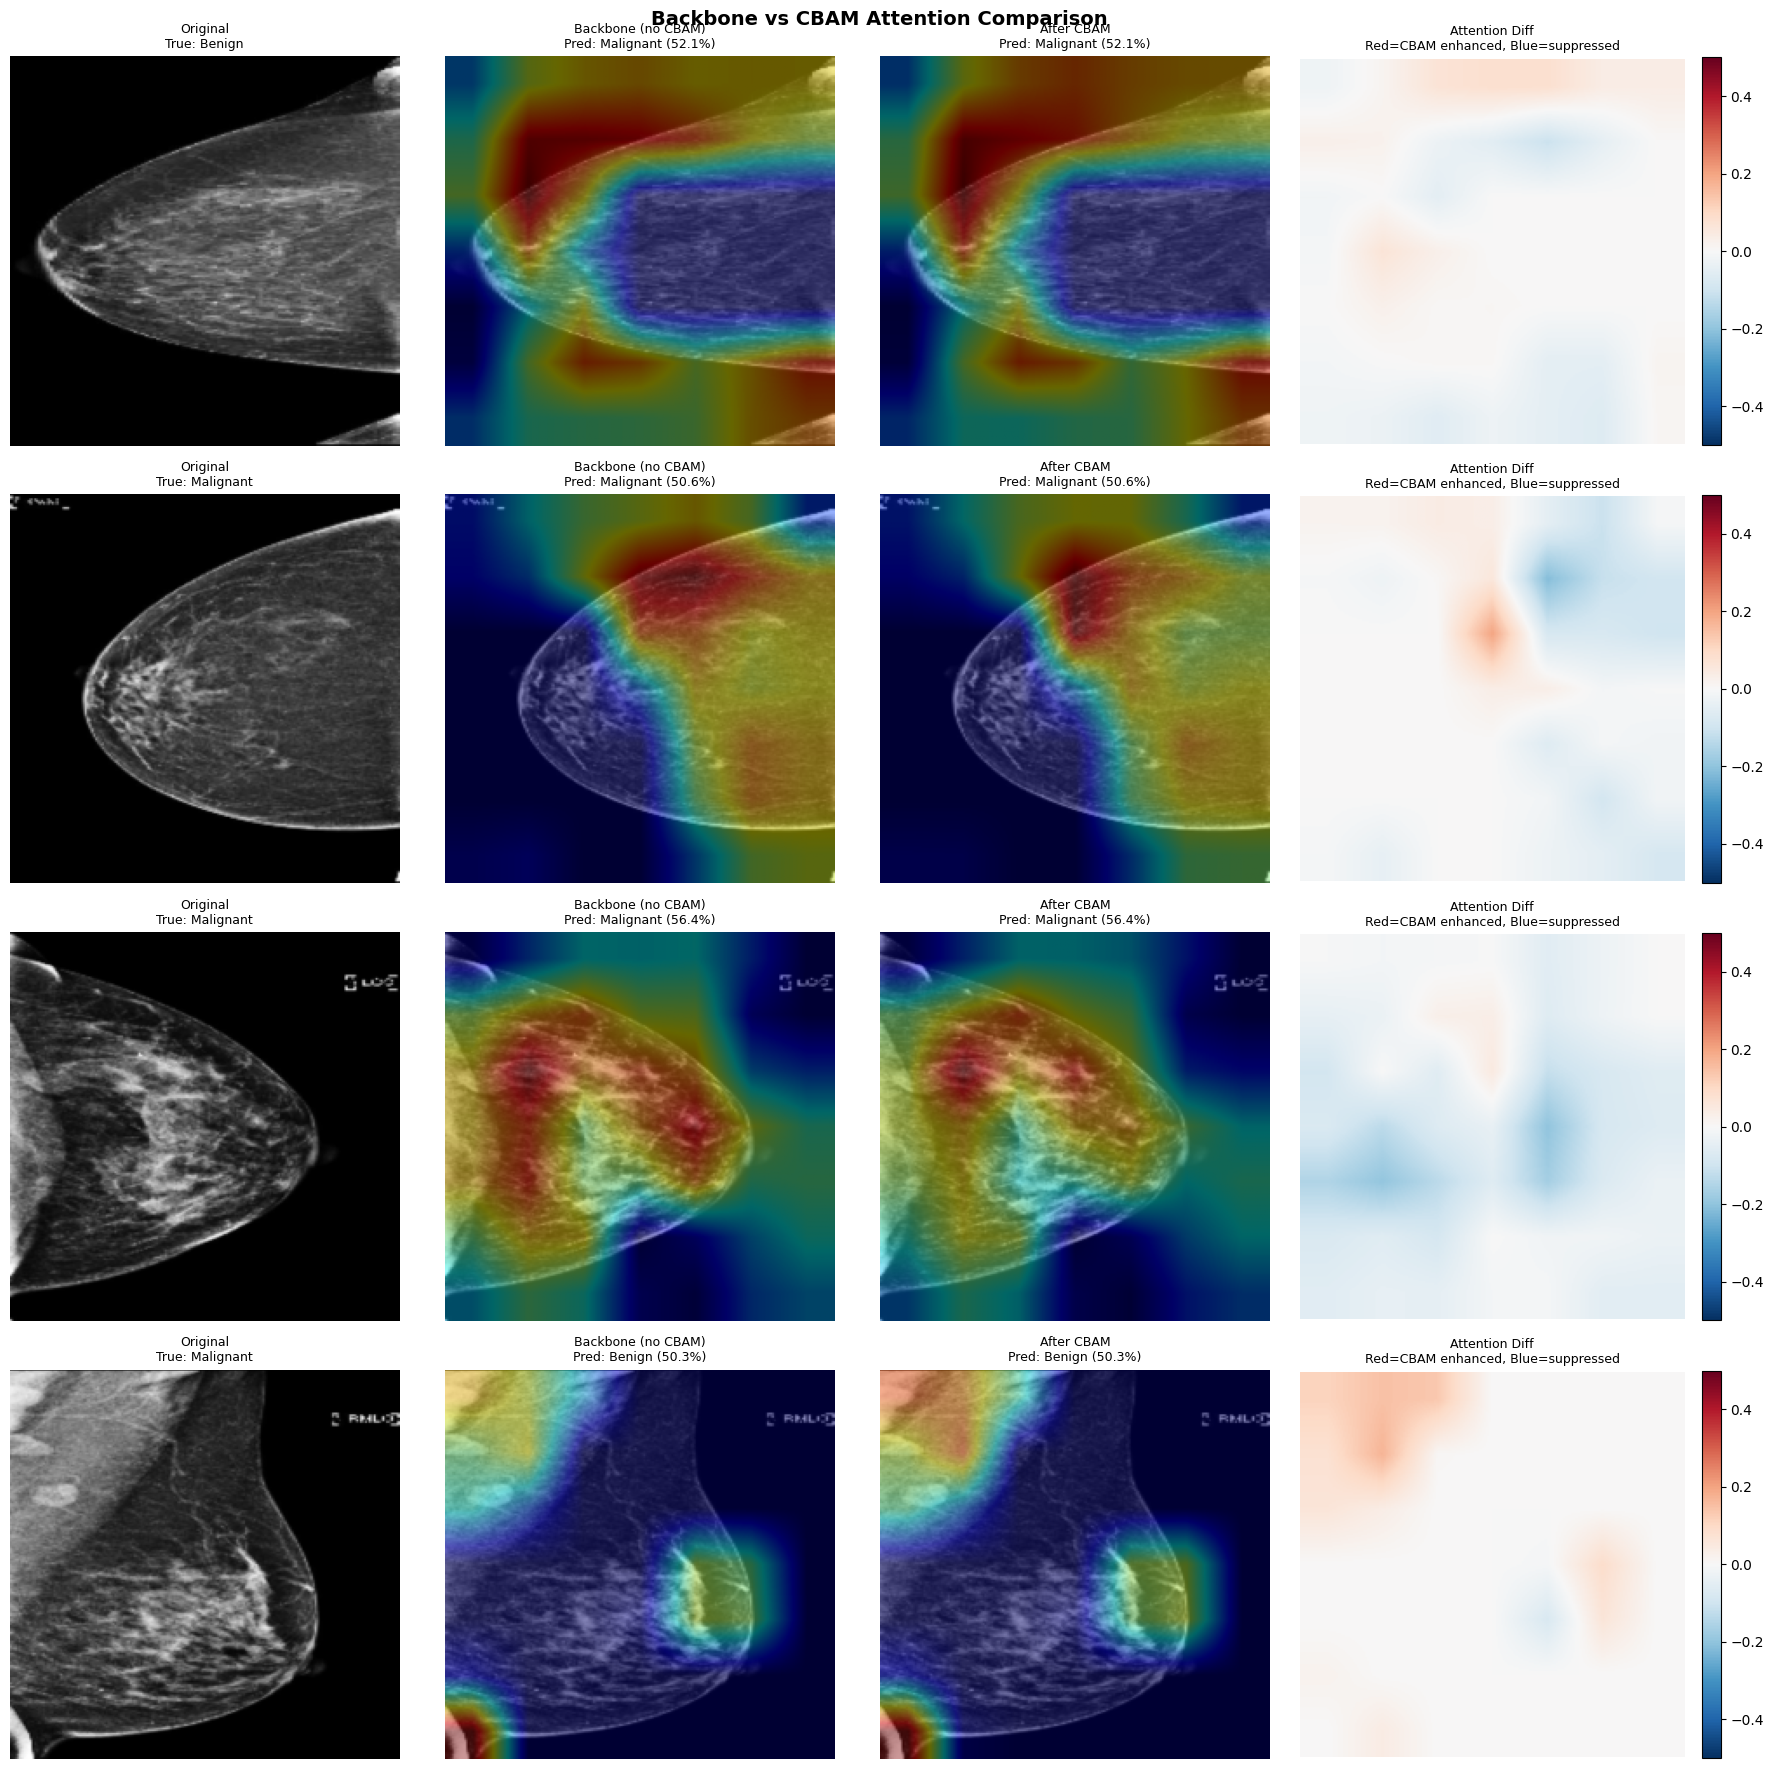

Saved to: /content/drive/MyDrive/breast cancer/gradcam_backbone_vs_cbam.png


In [ ]:
# Shows how CBAM shifts the model's attention compared to the raw backbone.
# Difference map: Red = enhanced by CBAM, Blue = suppressed by CBAM

print("\n" + "=" * 70)
print("Comparison: DenseNet121 backbone output vs CBAM-enhanced attention")
print("=" * 70)

grad_cam_backbone = GradCAM(model, target_layer=model.features)
grad_cam_cbam     = GradCAM(model, target_layer=model.cbam)

n_compare = 4
compare_indices = np.random.choice(selected_indices,
                                    min(n_compare, len(selected_indices)),
                                    replace=False)

fig, axes = plt.subplots(n_compare, 4, figsize=(18, 4.5 * n_compare))
if n_compare == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(compare_indices):
    image_tensor, true_label = valid_ds[idx]
    original = image_tensor[0].numpy()

    heatmap_bb, pred_bb, prob_bb = grad_cam_backbone.generate(
        image_tensor.unsqueeze(0).to(device).requires_grad_(True))
    overlay_bb = overlay_heatmap(original, heatmap_bb, alpha=0.4)

    heatmap_cb, pred_cb, prob_cb = grad_cam_cbam.generate(
        image_tensor.unsqueeze(0).to(device).requires_grad_(True))
    overlay_cb = overlay_heatmap(original, heatmap_cb, alpha=0.4)

    diff = heatmap_cb - heatmap_bb

    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 0].set_title(f'Original\nTrue: {CLASS_NAMES[true_label]}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(overlay_bb)
    axes[row, 1].set_title(f'Backbone (no CBAM)\nPred: {CLASS_NAMES[pred_bb]} ({prob_bb:.1%})', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay_cb)
    axes[row, 2].set_title(f'After CBAM\nPred: {CLASS_NAMES[pred_cb]} ({prob_cb:.1%})', fontsize=9)
    axes[row, 2].axis('off')

    im = axes[row, 3].imshow(diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[row, 3].set_title('Attention Diff\nRed=CBAM enhanced, Blue=suppressed', fontsize=9)
    axes[row, 3].axis('off')
    plt.colorbar(im, ax=axes[row, 3], fraction=0.046, pad=0.04)

plt.suptitle('Backbone vs CBAM Attention Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'gradcam_backbone_vs_cbam.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {os.path.join(base_dir, 'gradcam_backbone_vs_cbam.png')}")




## Cell 26: Attention Statistics — Verify Model Focuses on Correct Regions



Attention Distribution Analysis


Analyzing attention distribution: 100%|██████████| 50/50 [00:05<00:00,  9.07it/s]



Correct predictions (n=27):
  Center attention ratio : 0.316 +/- 0.112
  Max attention value    : 0.995 +/- 0.003
  Attention spread (std) : 0.249 +/- 0.051

Wrong predictions (n=23):
  Center attention ratio : 0.334 +/- 0.101
  Max attention value    : 0.994 +/- 0.003
  Attention spread (std) : 0.250 +/- 0.033


/tmp/ipykernel_5209/302284789.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels_bp, patch_artist=True)
/tmp/ipykernel_5209/302284789.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels_bp, patch_artist=True)
/tmp/ipykernel_5209/302284789.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=labels_bp, patch_artist=True)


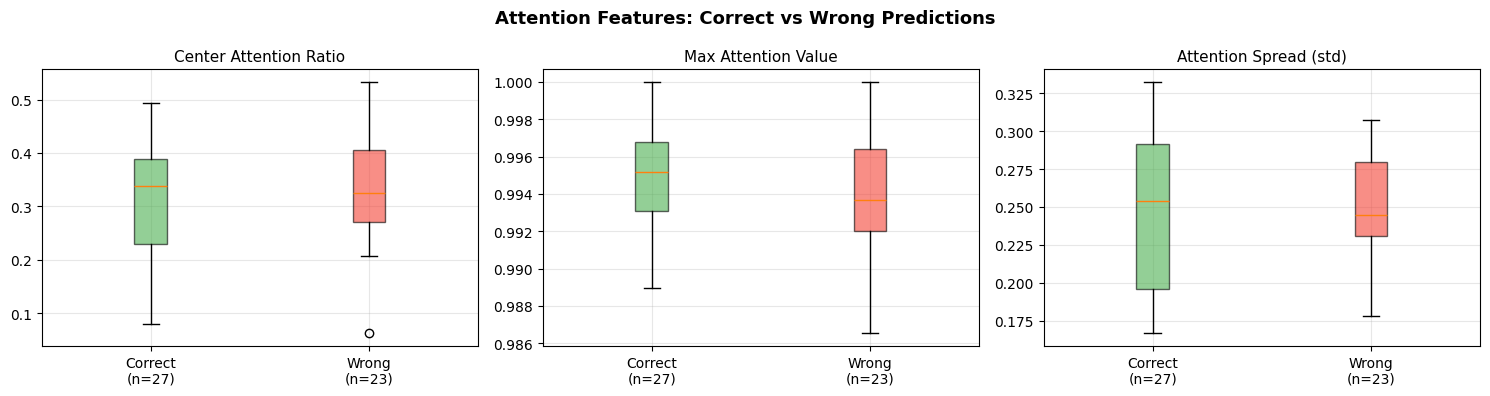


Saved to: /content/drive/MyDrive/breast cancer/attention_statistics.png

Interpretation guide:
  - If attention concentrates on edges or background -> model may be misled
  - If wrong predictions show overly diffuse attention -> CBAM is not focusing effectively
  - Ideal: attention should concentrate on abnormal tissue regions (masses / calcifications)


In [ ]:
print("\n" + "=" * 70)
print("Attention Distribution Analysis")
print("=" * 70)

n_analysis      = min(50, len(valid_ds))
analysis_indices = np.random.choice(len(valid_ds), n_analysis, replace=False)

attention_stats = {
    'correct': {'center_ratio': [], 'max_val': [], 'spread': []},
    'wrong':   {'center_ratio': [], 'max_val': [], 'spread': []},
}
grad_cam_analysis = GradCAM(model, target_layer=model.cbam)

for idx in tqdm(analysis_indices, desc="Analyzing attention distribution"):
    image_tensor, true_label = valid_ds[idx]
    input_tensor = image_tensor.unsqueeze(0).to(device).requires_grad_(True)
    heatmap, pred_class, _ = grad_cam_analysis.generate(input_tensor)

    key = 'correct' if pred_class == true_label else 'wrong'
    h, w = heatmap.shape

    # Center-region attention ratio (central 50% area)
    center_attention = heatmap[h//4:3*h//4, w//4:3*w//4].sum()
    total_attention  = heatmap.sum() + 1e-8
    attention_stats[key]['center_ratio'].append(center_attention / total_attention)
    attention_stats[key]['max_val'].append(heatmap.max())
    attention_stats[key]['spread'].append(heatmap.std())

# Print summary
for key in ['correct', 'wrong']:
    n = len(attention_stats[key]['center_ratio'])
    if n > 0:
        label = 'Correct predictions' if key == 'correct' else 'Wrong predictions'
        print(f"\n{label} (n={n}):")
        print(f"  Center attention ratio : {np.mean(attention_stats[key]['center_ratio']):.3f} "
              f"+/- {np.std(attention_stats[key]['center_ratio']):.3f}")
        print(f"  Max attention value    : {np.mean(attention_stats[key]['max_val']):.3f} "
              f"+/- {np.std(attention_stats[key]['max_val']):.3f}")
        print(f"  Attention spread (std) : {np.mean(attention_stats[key]['spread']):.3f} "
              f"+/- {np.std(attention_stats[key]['spread']):.3f}")

# Box plots comparing correct vs wrong predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['center_ratio', 'max_val', 'spread']
titles  = ['Center Attention Ratio', 'Max Attention Value', 'Attention Spread (std)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    data, labels_bp = [], []
    for key, label in [('correct', f'Correct\n(n={len(attention_stats["correct"][metric])})'),
                       ('wrong',   f'Wrong\n(n={len(attention_stats["wrong"][metric])})')]:
        if attention_stats[key][metric]:
            data.append(attention_stats[key][metric])
            labels_bp.append(label)
    if data:
        bp = axes[i].boxplot(data, labels=labels_bp, patch_artist=True)
        for patch, color in zip(bp['boxes'], ['#4CAF50', '#F44336'][:len(data)]):
            patch.set_facecolor(color); patch.set_alpha(0.6)
    axes[i].set_title(title, fontsize=11)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Attention Features: Correct vs Wrong Predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'attention_statistics.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved to: {os.path.join(base_dir, 'attention_statistics.png')}")
print("\nInterpretation guide:")
print("  - If attention concentrates on edges or background -> model may be misled")
print("  - If wrong predictions show overly diffuse attention -> CBAM is not focusing effectively")
print("  - Ideal: attention should concentrate on abnormal tissue regions (masses / calcifications)")
